## Marker genes

In [ ]:

canonical_markers_avail = [g for g in canonical_markers if g in h5_rna.var['gene_name'].values ]


# with plt.rc_context({'figure.figsize': (5, 5)}):
sc.pl.umap(h5_rna, color=canonical_markers_avail, wspace=0.1, ncols=4, size=40, gene_symbols='gene_name', layer='log1p_counts')

In [ ]:
sc.pl.umap(h5_rna, color=['SELL', 'IL7R', 'ITGAM'], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD127 protein : gene IL7R (T cells subtype)
# CD62L protein : gene SELL (T cells subtype)
# CD11B protein: ITGAM gene: T cells do not express ITGAM (myloid)

In [ ]:
sc.pl.umap(h5_rna, color=['CD3D', 'IL7R', 'CD8A', 'CD8B',  'NKG7', 'GNLY', 'FGFBP2', 'FCGR3A', 'FCER1G'], size=40 , gene_symbols='gene_name', layer='log1p_counts')

In [ ]:
sc.pl.umap(h5_rna, color=[ 'ITGAX',   'CD14','FCGR3A' ], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD11c protein: gene ITGAX -- DC 
# CD16 protein: gene FCGR3A -- NC monocytes

#### gamma-delta T cells 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'TRDC',   'TRGC1','TRDV2', 'TRGV9'], size=40 , ncols=2, gene_symbols='gene_name', layer='log1p_counts') #

### pDCs and C14+ monocytes

In [ ]:
sc.pl.umap(h5_rna, color=[ 'CD14', 'IRF7', 'TLR9', 'TCF4', 'CLEC4C' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

####  MAIT/NK-T cells 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'KLRG1',   'NCR3','KLRB1'], size=40 ,gene_symbols='gene_name', layer='log1p_counts') #

#### 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'NCAM1',   'TBX21','IFNG', 'NKG7', 'XCL2', 'NCR1' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

#### Mono 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'CD14',   'HLA-DRA', 'TNF', 'IL1B' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

In [ ]:
# cell-type idendification by Juliana

cluster_average_df = pd.DataFrame(index=h5_rna.var['gene_name'])

for c in h5_rna.obs['leiden_RNA_scVI'].unique():
    a = h5_rna[h5_rna.obs['leiden_RNA_scVI'] == c, :].layers['log1p_counts'].mean(axis=0)
    cluster_average_df[c] = np.asarray(a).flatten()
    
cluster_average_df.to_csv('HiJuliana_check_pbmc_rna_cluster_average_normalized_expression.csv')

cluster_average_df.head()

## Cell-type annotation from Julianaa

### Provicve clsuter to cell-type map

In [ ]:
# # Juliana's cell type annotation in the previous analysis (_missing1cell_DownstreamReanalysis subdir )
# RNAcluster_celltype_map = {
# '0': 'CD14+ Mo',
# '1': 'CD4+CD8+ naive T cells',
# '2': 'Tregs',
# '3': 'B cells',
# '4': 'ILC/NK cells',
# '5': 'MAIT/NK T cells',
# '6': 'gammaSignma T cells',
# '7': 'Unknown',
# '8': 'CD16+Mo',
# '9': 'pDCs',
# '10': 'Plasma cells (noisy)'
# }
# h5_rna.obs['celltype'] = h5_rna.obs['leiden_RNA_scVI'].map(RNAcluster_celltype_map)

# ## do NOT !!! delete 
# ## do NOT !!! delete 
# ## do NOT !!! delete 


# # ## Save each cell-type's barcode 
# # rna_cell_type_subdir = os.path.join(entropy_dir,  '_rna_cell_types')
# # os.makedirs(rna_cell_type_subdir, exist_ok=True)

# # for cluster in h5_rna.obs['leiden_RNA_scVI'].unique():
# #     write_file = 'RNAcluster_' + str(cluster) + '_df.csv' 
# #     write_file_path = os.path.join(rna_cell_type_subdir, write_file)
# #     h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == cluster, :].to_csv(write_file_path, index=False)    
# # # write cell-type mapping file
# # celltype_map_file = os.path.join(rna_cell_type_subdir, 'RNAcluster_celltype_map.tsv')
# # with open(celltype_map_file, 'w') as f:
# #     for k, v in RNAcluster_celltype_map.items():
# #         f.write(f"{k}\t{v}\n")



# Load fragments to calculate percentage in CTCF regions

In [30]:
Union_cell_subdir=os.path.join(entropy_dir, '_cell_palling_comparison')


cCREs_frag_subdir = os.path.join(Union_cell_subdir, 'cCREs_over_frag')

H3K4me3_CTCF_frag_file=os.path.join(cCREs_frag_subdir, 'fragments_H3K4me3_CTCF.tsv')
CTCF_CTCF_frag_file=os.path.join(cCREs_frag_subdir, 'fragments_CTCF_CTCF.tsv')
pELS_CTCF_frag_file=os.path.join(cCREs_frag_subdir, 'fragments_pELS_CTCF.tsv')
dELS_CTCF_frag_file=os.path.join(cCREs_frag_subdir, 'fragments_dELS_CTCF.tsv')
PLS_CTCF_frag_file=os.path.join(cCREs_frag_subdir, 'fragments_PLS_CTCF.tsv')


H3K4me3_CTCF_frag = pd.read_csv(H3K4me3_CTCF_frag_file, sep='\t', header=None)
CTCF_CTCF_frag = pd.read_csv(CTCF_CTCF_frag_file, sep='\t', header=None)
pELS_CTCF_frag = pd.read_csv(pELS_CTCF_frag_file, sep='\t', header=None)
dELS_CTCF_frag = pd.read_csv(dELS_CTCF_frag_file, sep='\t', header=None)
PLS_CTCF_frag = pd.read_csv(PLS_CTCF_frag_file, sep='\t', header=None)


for df in [H3K4me3_CTCF_frag, CTCF_CTCF_frag, pELS_CTCF_frag, dELS_CTCF_frag, PLS_CTCF_frag]:
    df.columns = ['chrom', 'start', 'end', 'atac_barcodes', 'bp_overlap']
    df['atac_bc'] = df['atac_barcodes'].map(lambda x: x.split('-1')[0])

In [31]:
H3K4me3_CTCF_perbc = H3K4me3_CTCF_frag.groupby('atac_bc').size().to_frame('H3K4me3_CTCF_frag_count')
CTCF_CTCF_perbc = CTCF_CTCF_frag.groupby('atac_bc').size().to_frame('CTCF_CTCF_frag_count')
pELS_CTCF_perbc = pELS_CTCF_frag.groupby('atac_bc').size().to_frame('pELS_CTCF_frag_count')
dELS_CTCF_perbc = dELS_CTCF_frag.groupby('atac_bc').size().to_frame('dELS_CTCF_frag_count')
PLS_CTCF_perbc = PLS_CTCF_frag.groupby('atac_bc').size().to_frame('PLS_CTCF_frag_count')



In [32]:
if 'H3K4me3_CTCF_frag_count' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(H3K4me3_CTCF_perbc, left_on='atac_barcodes', right_index=True, how='left')

if 'CTCF_CTCF_frag_count' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(CTCF_CTCF_perbc, left_on='atac_barcodes', right_index=True, how='left')

if 'pELS_CTCF_frag_count' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(pELS_CTCF_perbc, left_on='atac_barcodes', right_index=True, how='left')

if 'dELS_CTCF_frag_count' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(dELS_CTCF_perbc, left_on='atac_barcodes', right_index=True, how='left')

if 'PLS_CTCF_frag_count' not in h5_rna.obs.columns:
    h5_rna.obs = h5_rna.obs.merge(PLS_CTCF_perbc, left_on='atac_barcodes', right_index=True, how='left')

for col in  ['H3K4me3_CTCF_frag_count', 'CTCF_CTCF_frag_count', 'pELS_CTCF_frag_count', 'dELS_CTCF_frag_count', 'PLS_CTCF_frag_count']:
    h5_rna.obs[col].fillna(0, inplace=True)

h5_rna.obs['H3K4me3_CTCF_frag%'] = h5_rna.obs['H3K4me3_CTCF_frag_count'].fillna(0) / h5_rna.obs['total_fragments'] * 100
h5_rna.obs['CTCF_CTCF_frag%'] = h5_rna.obs['CTCF_CTCF_frag_count'].fillna(0) / h5_rna.obs['total_fragments'] * 100
h5_rna.obs['pELS_CTCF_frag%'] = h5_rna.obs['pELS_CTCF_frag_count'].fillna(0) / h5_rna.obs['total_fragments'] * 100
h5_rna.obs['dELS_CTCF_frag%'] = h5_rna.obs['dELS_CTCF_frag_count'].fillna(0) / h5_rna.obs['total_fragments'] * 100
h5_rna.obs['PLS_CTCF_frag%'] = h5_rna.obs['PLS_CTCF_frag_count'].fillna(0) / h5_rna.obs['total_fragments'] * 100

/tmp/ipykernel_625352/2091766777.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  h5_rna.obs[col].fillna(0, inplace=True)


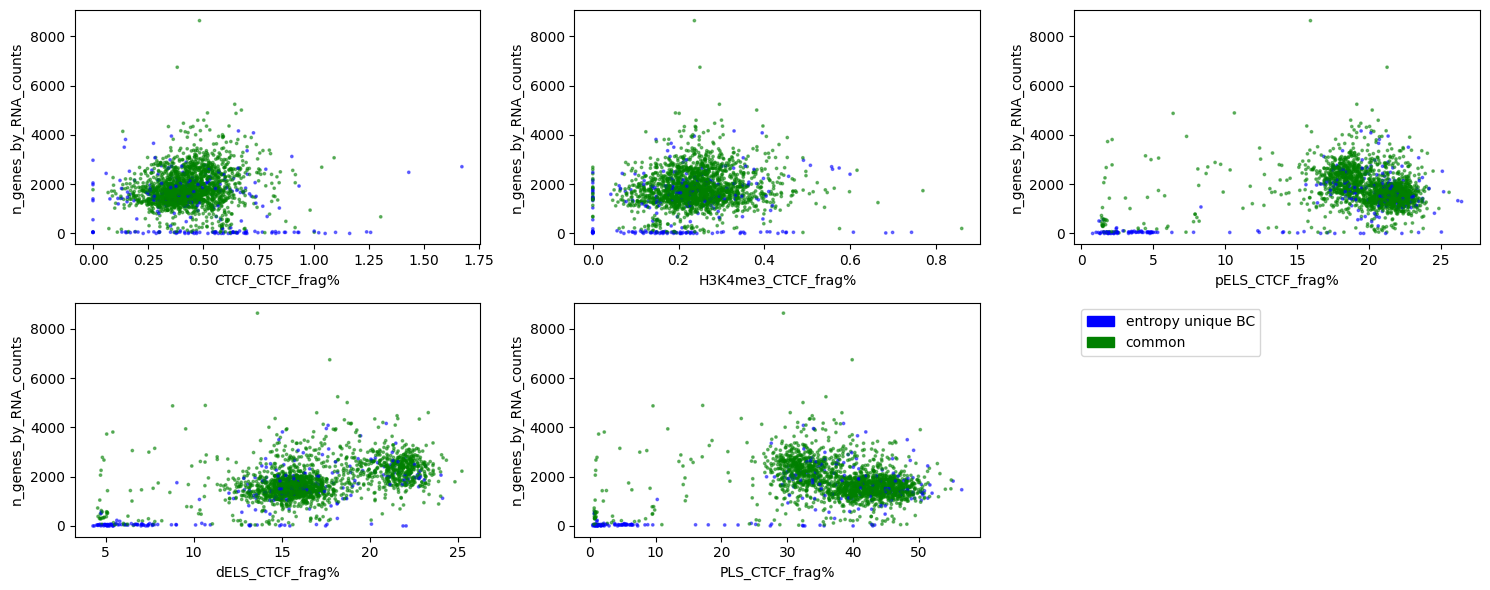

In [33]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))
ax = ax.flatten()

ctcf_types = ['CTCF_CTCF_frag%', 'H3K4me3_CTCF_frag%', 'pELS_CTCF_frag%', 'dELS_CTCF_frag%', 'PLS_CTCF_frag%']

for i, ctcf in enumerate(ctcf_types):
    ax[i].scatter(h5_rna.obs[ctcf],
           h5_rna.obs['n_genes_by_RNA_counts'] , alpha=0.5, s=3, c=h5_rna.obs['_2set_identified_by_atac_SC'].map({'entropy_only': 'blue', 'both': 'green'}))
    ax[i].set_xlabel(ctcf)
    ax[i].set_ylabel('n_genes_by_RNA_counts')
    
ax[5].legend(handles=[mpatches.Patch(color='blue', label='entropy unique BC'), mpatches.Patch(color='green', label='common')], loc='upper left')
ax[5].axis('off')
plt.tight_layout()


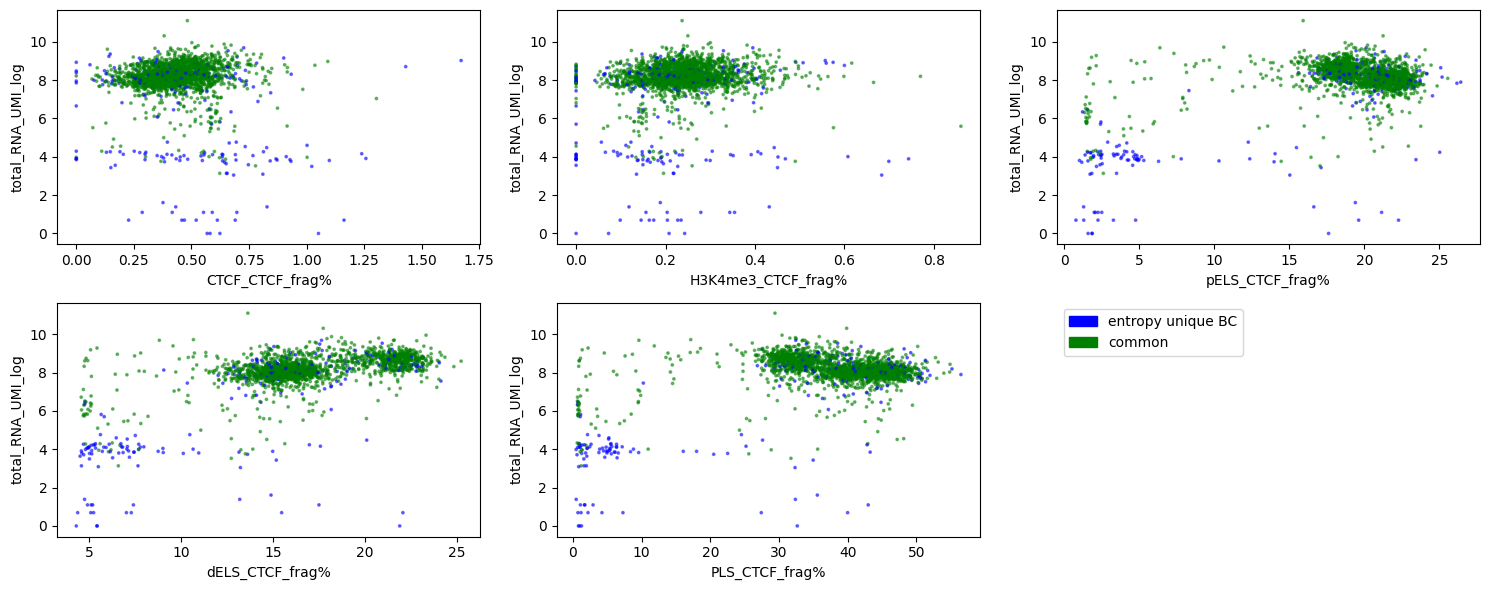

In [34]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))
ax = ax.flatten()

ctcf_types = ['CTCF_CTCF_frag%', 'H3K4me3_CTCF_frag%', 'pELS_CTCF_frag%', 'dELS_CTCF_frag%', 'PLS_CTCF_frag%']

for i, ctcf in enumerate(ctcf_types):
    ax[i].scatter(h5_rna.obs[ctcf],
           h5_rna.obs['total_RNA_UMI_log'] , alpha=0.5, s=3, c=h5_rna.obs['_2set_identified_by_atac_SC'].map({'entropy_only': 'blue', 'both': 'green'}))
    ax[i].set_xlabel(ctcf)
    ax[i].set_ylabel('total_RNA_UMI_log')
    
ax[5].legend(handles=[mpatches.Patch(color='blue', label='entropy unique BC'), mpatches.Patch(color='green', label='common')], loc='upper left')
ax[5].axis('off')
plt.tight_layout()

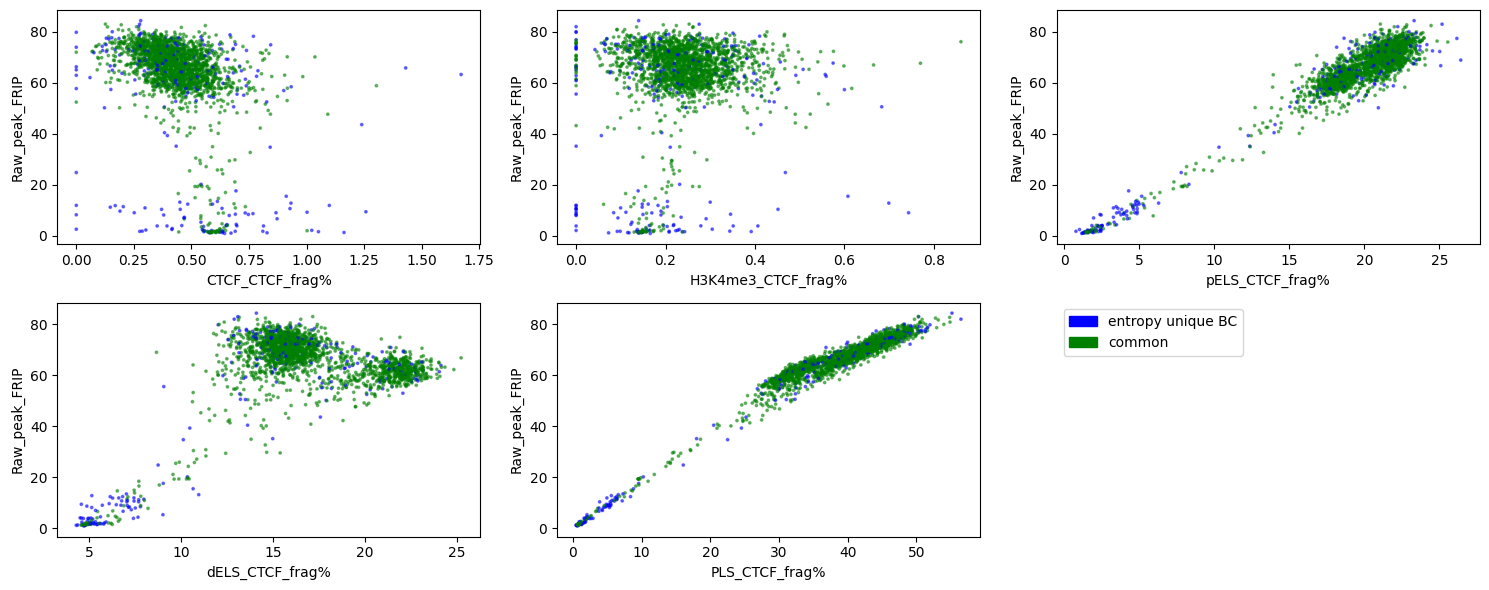

In [35]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))
ax = ax.flatten()

ctcf_types = ['CTCF_CTCF_frag%', 'H3K4me3_CTCF_frag%', 'pELS_CTCF_frag%', 'dELS_CTCF_frag%', 'PLS_CTCF_frag%']

for i, ctcf in enumerate(ctcf_types):
    ax[i].scatter(h5_rna.obs[ctcf],
           h5_rna.obs['Raw_peak_FRIP'] , alpha=0.5, s=3, c=h5_rna.obs['_2set_identified_by_atac_SC'].map({'entropy_only': 'blue', 'both': 'green'}))
    ax[i].set_xlabel(ctcf)
    ax[i].set_ylabel('Raw_peak_FRIP')
    
ax[5].legend(handles=[mpatches.Patch(color='blue', label='entropy unique BC'), mpatches.Patch(color='green', label='common')], loc='upper left')
ax[5].axis('off')
plt.tight_layout()

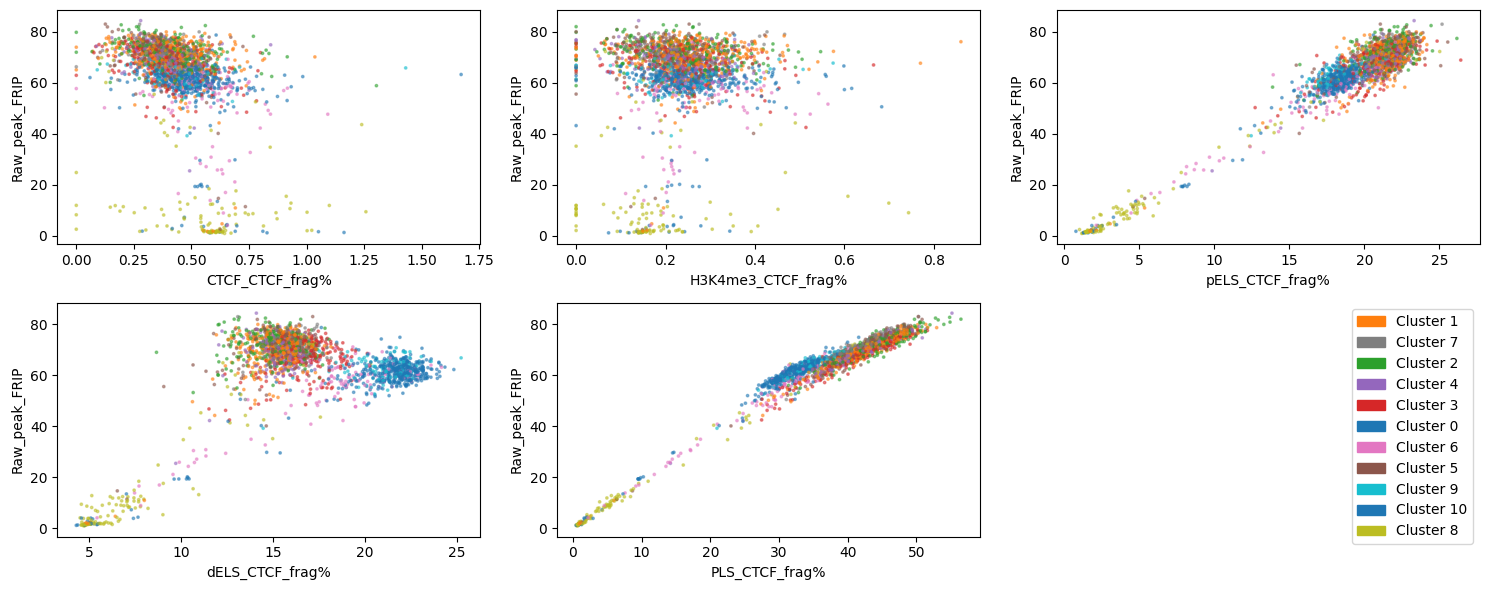

In [36]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 6))
ax = ax.flatten()

ctcf_types = ['CTCF_CTCF_frag%', 'H3K4me3_CTCF_frag%', 'pELS_CTCF_frag%', 'dELS_CTCF_frag%', 'PLS_CTCF_frag%']

for i, ctcf in enumerate(ctcf_types):
    ax[i].scatter(h5_rna.obs[ctcf],
           h5_rna.obs['Raw_peak_FRIP'] , alpha=0.5, s=3, c=h5_rna.obs['leiden_RNA_scVI'].map(lambda x: f"C{int(x)}"))
    ax[i].set_xlabel(ctcf)
    ax[i].set_ylabel('Raw_peak_FRIP')
    
ax[5].legend(handles=[mpatches.Patch(color=f"C{int(c)}", label=f"Cluster {c}") for c in h5_rna.obs['leiden_RNA_scVI'].unique()], loc='upper right', bbox_to_anchor=(1, 1))
ax[5].axis('off')
plt.tight_layout()

## Plot to see consistency between atac space and rna space 

Text(0.5, 0, 'Entropy value (log)')

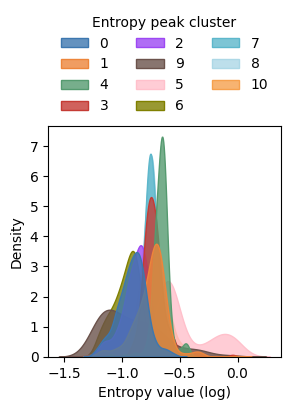

In [57]:
color_order = {'0': '#3d77af', '1': '#ed853b', '2': '#559a6f', '3': '#c53b34', '4': '#9d48f3',
             '5': '#6b524b', '6': 'pink', '7': 'olive', '8': '#5db7cb', '9': 'lightblue', 
                '10': '#f6a04d', '11': '#8fd18b', '12': 'lightcoral'}#, '13': 'lime'}
entropy_peak_cluster_order = h5_rna.obs['reorder_clusters_peakvi_highres_entropy'].cat.categories.tolist()
color_map = {k: color_order[str(i)] for i, k in enumerate(entropy_peak_cluster_order)}

fig, ax = plt.subplots(figsize=(3, 3))
kde = sns.kdeplot(data=h5_rna.obs, x='Entropy_log', hue='reorder_clusters_peakvi_highres_entropy', 
                  palette=color_map,
                  fill=True, 
                  ax=ax, alpha=0.8, common_norm=False)
sns.move_legend(
    kde, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title='Entropy peak cluster', frameon=False
)

ax.set_xlabel('Entropy value (log)')
